# φ4 Hamiltonian Truncation on a Circle

Builds the truncated Hamiltonian for an interacting scalar field in 1+1D on a circle of radius $r$:

$$H_\text{eff} = H_0 + \frac{g}{24} H_4$$


and studies how the energy gap $E_1^+ - E_0$ converges as the energy cutoff $E_\mathrm{max}\to\infty$.

Reference: arXiv:2507.15941


In [1]:
import math

import numpy as np
import scipy.sparse as sp

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns



from collections import Counter, defaultdict
import csv

%matplotlib inline

## 1. Single-particle energy and mode indexing

Modes are labelled by magnitude $l \ge 0$ (momentum $\pm l/r$) and sign $\sigma = \pm 1$.
States are stored as dictionaries `{...,-l₂:n₂₋,-l₁:n₁₋,l₀:n₀,l₁:n₁₊,l₂:n₂₊,...}`.


In [2]:
def omega(l, mQ, r):
    # State Energy
    return math.sqrt(float(l)*float(l)/(r*r) + mQ*mQ)

def gen_omega_list(lmax, mQ, r):
    # Global variable storing a list of all state energies.
    global omega_list
    omega_list = [omega(abs(l), mQ, r) for l in range(0,lmax+1)]

# --- Helper functions ---
def get_total_occupation_number(state):
    # Returns occupation number for a given state in dictionary format.
    return sum(state.values())


def convert_state_to_list(state, lmax):
    # Returns state held in dictionary to list.
    return [state.get(i, 0) for i in range(-lmax, lmax+1)]


def get_state_energy(state, mQ, r):
    # Returns state energy for state in dictionary format.
    return sum([nl*omega(l, mQ, r) for l, nl in state.items()])

## 2. Basis generation via the change problem

The change problem is essentially how many ways can you make change for some quantity given a set of coins. Here we have any angular momentum state.

`gen_coins` builds a dictionary with all of the ways to create a number by summing smaller numbers. This is stored in the global state `coins` and will allow us to automatically build states in the **zero-total-momentum** sector (`l_total == 0`).
Elements of the `coins` dictionary appear as e.g. `{5:[[5],[4,1],[3,2],[3,1,1],[2,1,1,1],[1,1,1,1,1]}`.

`coin_dict` then turns the global dictionary `coins` into a global frequency dictionary `coinDict`. Elements of `coinDict` appear as, e.g. `{5:[Counter({4:1}),Counter({3:1,1:1}),Counter({2:2},Counter({2:1,1:2}),Counter({1:4})}`. 

`coin_energies` computes a list of energies for each set of coins labelled by `l` in `coins`. As positive and negative `l` states have the same energy, this only needs computing once.



In [3]:
def gen_coinDict(coins):
    #Turns coins into a global counting dictionary, which is easier to perform operations on.
    global coinDict
    coinDict = {}
    for key in coins.keys():
        coinDict[key] = [Counter(reversed(val)) for val in coins[key]]
        

def gen_coins(n_max):
    global coins
    # Creates the coins dictionary if it does not already exist.
    if 'coins' not in globals():
        coins = {}
        coins.setdefault(1,[[1]]) 
        
    # If we have already calculated up to n_max, just return the dictionary.
    if n_max in coins: return(coins)
     

    for i in range(max(coins.keys())+1,n_max+1):
        #This step is a little complicated so I'll break it down into the two parts of the sum:
        #   1. The first part adds [1] to the end of every list for the previous element (e.g. 6:[[6],...] -> 7:[...,[6, 1],...])
        #   2. The second part adds 1 to the final element of the previous interation (e.g. 6:[...,[3,2,1],...]->7:[...,[3,2,2],...]) given the following conditions:
        #       a) If the length of the dictionary is 1, just add one (i.e 6:[[6],..] -> 7:[[7],...])
        #       b) If the final two elements of a list are the same, there also exists one where the final two elements differ by two (e.g. 6:[...,[3,3],[4,2],...]).
        #          Without input, this would result in duplicate entries. Therefore, the final two elements must not be equal for this step.

        coins[i] = [cns[:-1]+[cns[-1]+1] for cns in coins[i-1] if (len(cns)==1 or cns[-2]!=cns[-1])] + list(map(lambda x:x+[1], coins[i-1])) 
        #coins[i] = sorted(coins[i], key=len) #Not sure this helps. But re-ordering the coin dictionary after creation in terms of occupation number.
        
    # Creating a counting dictionary version of this as it is easier to perform operations on.
    gen_coinDict(coins)
    return coins


def coin_energies(l,mQ,r):
    #Computes the energies of each possible change.
    return [sum(map(lambda c: omega(c, mQ, r), change)) for change in coins[l]]
            

In [4]:
#Example of the coins. 
gen_coins(4)
#Just printing states 3 and 4.
for i in range(3,5):
    print(f'lmax = {i}')
    for change in coins[i]:
        print(f'Coins = {change}, Energy = {sum(map(lambda c: omega(c, 1, 1), change))}')

lmax = 3
Coins = [3], Energy = 3.1622776601683795
Coins = [2, 1], Energy = 3.6502815398728847
Coins = [1, 1, 1], Energy = 4.242640687119286
lmax = 4
Coins = [4], Energy = 4.123105625617661
Coins = [2, 2], Energy = 4.47213595499958
Coins = [3, 1], Energy = 4.576491222541475
Coins = [2, 1, 1], Energy = 5.06449510224598
Coins = [1, 1, 1, 1], Energy = 5.656854249492381


## Generating the set of basis states

`gen_reduced_basis` builds all occupation-number states with energy ≤ `e_max`, by `l` iterating up to `lmax` and each time merging two `coinDicts` together (one with negative angular momentum). Zero momentum states are then added up to `e_max`. This produces all ways to build states with `l_total == 0`.

To note about this particular method:

1. States are stored in dictionary form i.e. `{l:nl,...}` where `l` is the angular momentum and `nl` is the corresponding occupancy number.

2. This particular method only produces one in a pair of asymmetric states about `l=0`. For example `{-3:1,1:3}` would be asymmetric. For larger `e_max` just less than 1/2 of the states are asymmetric so this aids in reducing computation time later.

3. States are produced with the ordering such that `l` goes from most negative to most positive for each state in the basis.

4. a `conversionDict` is concurrently produced which maps indices from the reduced to full basis (including asymmetric pairs). Note asymmetric pairs carry the same index at this stage, where it is understood you will have to manually index +1 to the flipped companion state as required. The next state will have index+2.

In [5]:
def gen_reduced_basis(lmax, e_max, mQ, r):
    asymList = [] # List of states which are asymmetric.

    #l=0:
    result = [{0: 0}] # The empty state.
    conversionDict = {0:0} # Dictionary to allow fast conversion between reduced and complete basis indices.

    for i in range(1, int(math.floor(e_max/mQ)) + 1): # Adding l=0 states up to the maximum possible number allowed before reaching e_max.
        result+=[{0: i}] 
        conversionDict[i]=i

    #l>0:

    # ix is the running state index which we set to one above the maximum l=0 occupancy.
    # asymList is a set (hashable) containing the indices of asymmetric states.
    # runner keeps track of how many asymmetric states there have previously been to produce the conversion dict.
    ix = int(math.floor(e_max/mQ))+1; asymList = set(); runner = 0 
    
    
    for l in range(1,lmax+1):
        gen_coins(l) # All ways of making up to lmax with smaller numbers
        gen_coinDict(coins) # Generates a dictionary version
        coinEnergies = coin_energies(l,mQ,r) # Energies for each set of coins.

        # Iterate through positive (ii, ci) and negative (jj, cj) momenta, then merge dictionaries.
        for ii,ci in enumerate(coinDict[l]):
            for jj,cj in enumerate(coinDict[l]):
                if jj>=ii: # Only make one copy of each asymmetric state.

                    #Build a temporary energy for the state so we can 
                    # A) figure out if it exceeds e_max.
                    # B) add l=0 states successively up to e_max.
                    e_temp = e_max - coinEnergies[ii] - coinEnergies[jj]
                    
                    if e_temp > 0: #Fill up l=0 state up to e_max.

                        # Merge positive and negative l states, with total l=0. 

                        negative_ci = {-jjj:cjj for jjj,cjj in reversed(cj.items())} # 'reversed' operation here gives correct l-ordering in the state dictionary. NOTE this is not strictly guaranteed to be maintained so we should adjust this.
                        
                        result+=[ negative_ci | ci ]
                        conversionDict[ ix ] = ix + runner

                        if ii!=jj: 
                            # Populating the asymList dictionary as states are asymmetric.
                            asymList.add(ix)
                            # Add one to runner for conversion.
                            runner += 1 

                        # Increase state index.
                        ix += 1

                        # Now adding successively more l=0 states up to total e_max.
                        for i in range(1, int(math.floor(e_temp/mQ)) + 1):

                            # Adding successively more l=0 states up to e_max in the center of the dictionary.
                            result+=[ negative_ci | {0:i} | ci ]
                            conversionDict[ ix ] = ix + runner

                            if ii!=jj: 
                                # Populating the asymList dictionary as states are asymmetric.
                                asymList.add(ix)
                                # Add one to runner for conversion.
                                runner += 1

                            ix += 1
                            
                        
                
    return (result, asymList, conversionDict)

In [6]:
# To restore both asymmetric pairs of each state in the reduced basis. It does this by running through indices in asymList and  that state.
def convertBasis(reduced_basis, asymList):
    new_basis = reduced_basis.copy(); runner = 1
    for ix in sorted(asymList): # Running through indexes in asymList (i.e. list of non-symmetric states)
        new_basis.insert(ix+runner,{-l:nl for l, nl in reduced_basis[ix].items()}) # Flipping the sign of l for each object in basis. Preserves ordering of l's in dictionary.
        runner += 1
        
    return new_basis

In [7]:
#Helper function which calculates the maximum angular momentum pairs which can be produced, still below e_max.
def effective_lmax(lmax, e_max, mQ, r):
    if mQ**2 < e_max**2 / 4:
        return int(min(lmax, math.floor(math.sqrt(max(0, r**2*(e_max**2/4 - mQ**2))))))
    return 0

## 3. Basis Generation Timing Between 2110.08273 Method and New Method

Must compute the timing with 2110.08237 in a different notebook and import as "benchmark_basisgen_results.csv"

In [8]:
# Hamiltonian Parameters.
mQ = 1; r = 10/(2*math.pi) 

# Lists to hold the timing result and basis lengths.
execution_times = []; len_basis = []
emax_list = range(6,20) #Test Range of E_max.


# 1. Iterate over emax_list
for emax in emax_list:
    print(f"E_max: {emax}")
    lmaxeff = effective_lmax(emax,emax,mQ,r)
    
    # Using timeit to get accurate generation timings.
    duration = %timeit -o gen_reduced_basis(lmaxeff,emax,mQ,r)
    # Generating the basis via the above method so we can find it's length.
    basis,asymList,_ = gen_reduced_basis(lmaxeff,emax,mQ,r)
    
    # Adding execution timings and full basis length to the result.
    execution_times.append(duration.average)
    len_basis.append(len(basis)+len(asymList))
    
    del coins #For fairness, reset the coins dictionary each time.
    
    

# 2. Importing comparison timings. This file is produced from the code of https://arxiv.org/abs/2110.08273 and imported here.
csv_filename = "benchmark_basisgen_results.csv"
execution_times_prev = []; emax_list_prev = []
with open(csv_filename, mode="r") as file:
    reader = csv.reader(file)
    
    # Prints Hamiltonian parameters for benchmark. Confirm that these are the same in-use here!
    print('--- Benchmark Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_list_prev = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader)  # And skips Header for result array.
    for row in reader:
        execution_times_prev.append(float(row[1])) # Convert time back to float

# 3. Plot the results
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel(r'$E_\text{max}$', color='black')
ax1.set_ylabel('Time in Seconds (Log Scale)')
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelcolor='black')
ax1.grid(True, which="both", linestyle='--', alpha=0.5)


ax1.plot(emax_list, execution_times, marker='o', linestyle='-', color='b', label='New Method')
ax1.plot(emax_list_prev, execution_times_prev, marker ='o', linestyle='-', color='r', label='2110.08273 Method')

# 4. First degree polynomial fit to the timing data.
coef_new = (np.polyfit(emax_list, np.log10(execution_times), 1))
coef_old = (np.polyfit(emax_list_prev, np.log10(execution_times_prev), 1))
poly_new = np.poly1d(coef_new)
poly_old = np.poly1d(coef_old)
xs = np.linspace(emax_list[1],emax_list[-1])

ax1.plot(xs, 10**poly_new(xs), linestyle='--', color='b', label=f'New Fit $log(t)={coef_new[0]:.1f}x+{coef_new[1]:.1f}$')
ax1.plot(xs, 10**poly_old(xs), linestyle='--', color='r', label=f'2110.08273 Fit $log(t)={coef_old[0]:.1f}x+{coef_old[1]:.1f}$')
ax1.legend()

# --- A second x-axis to show the basis length. 
ax2 = ax1.twiny() 
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(emax_list) 

formatted_top_labels = []
for x in len_basis:
    if x>10000:# Cleaning up long numbers into standard form.
        base, exponent = f"{x:.0e}".split("e")
        # Clean up the sign on the exponent (e.g., +06 becomes 6)
        exponent = int(exponent) 
        # Wrap in LaTeX math style for superscripts
        formatted_top_labels.append(f"${base} \\times 10^{{{exponent}}}$")
    else:
        # Otherwise using the original number.
        formatted_top_labels.append(x)
    
ax2.set_xticklabels(formatted_top_labels) 
ax2.set_xlabel('Basis Length', color='blue')
ax2.tick_params(axis='x', labelcolor='blue')


plt.title(r'Basis Generation Time vs $E_\text{max}$')
plt.show()


E_max: 6
42.4 μs ± 376 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
E_max: 7


KeyboardInterrupt: 

## 3. State Occupation Plot

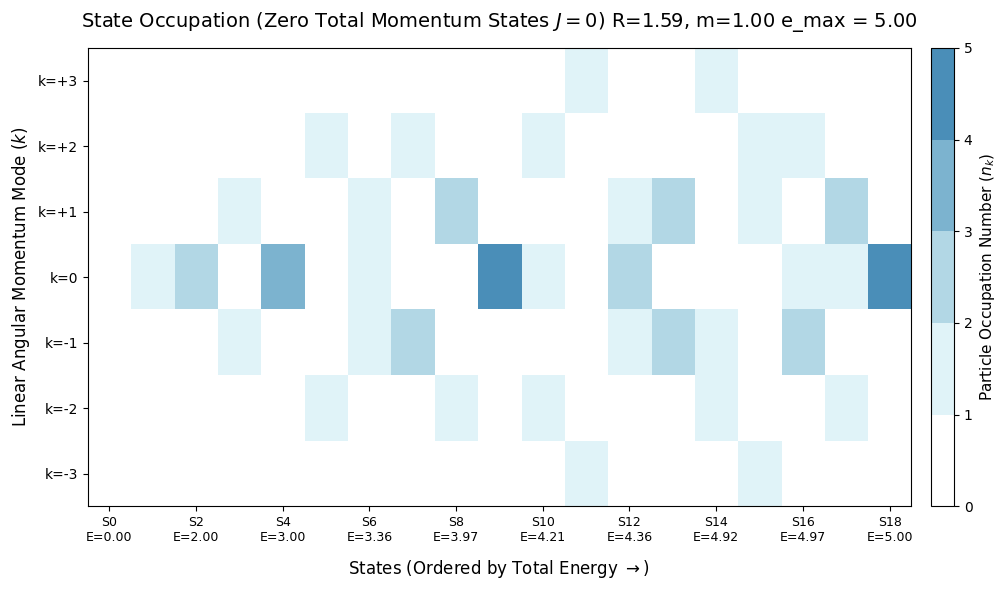

In [9]:
# Hamiltonian Truncation Perameters.
mQ = 1; r = 10/(2*math.pi); e_max=5; lmaxeff = effective_lmax(e_max,e_max,mQ,r)

# Generate the basis.
reduced_basis, asymList, cD = gen_reduced_basis(lmaxeff,e_max,mQ,r)

basis = convertBasis(reduced_basis,asymList)
# Possible Angular Momenta
modes = list(range(-lmaxeff, lmaxeff+1))


# --- Sort states by energies (E = sum(sqrt(1 + k^2))) ---
sorted_states = []
# Computing the energies
state_energies = []
for state in basis:
    state_energies.append(sum([nl*omega(l, mQ, r) for l, nl in state.items()]))

# Sorting the states by energy.
sorted_states=[x for x, _ in sorted(zip(basis, state_energies), key=lambda pair: pair[1])]
sorted_energies=sorted(state_energies)

# --- Construct the Grid of Angular Momenta on the y-axis with States of Increasing Energies on x-axis ---
grid_matrix = np.zeros((len(modes), len(sorted_states)))
for col_idx, stateDict in enumerate(sorted_states):
    grid_matrix[:, col_idx] = [stateDict[x] if x in stateDict else 0 for x in modes]


# --- Plotting the Grid Heatmap ---
fig, ax = plt.subplots(figsize=(11, 6))

#DISCRETE COLOUR MAP for the plot. Add more colours if more than 10 occupation number required.:
blue_gradient = [
    '#ffffff', '#e0f3f8', '#b2d7e5', '#7cb3cf', '#4a8eb8',
    '#2367a0', '#0e457f', '#022659', '#001035', '#000314'
]
blue_cmap = ListedColormap(blue_gradient[:int(max(np.ndarray.flatten(grid_matrix)))])
# origin='lower' keeps negative momentum at the bottom and positive at the top
cax = ax.imshow(grid_matrix, cmap=blue_cmap, aspect='auto', origin='lower',interpolation='nearest')

# Axis Configuration (Y-Axis: Momentum)
mode_labels = [f"k={m}" if m <= 0 else f"k=+{m}" for m in modes] # Separating positive and negative angular momenta.
ax.set_yticks(np.arange(len(modes)))
ax.set_yticklabels(mode_labels, fontsize=10)
ax.set_ylabel("Linear Angular Momentum Mode ($k$)", fontsize=12)

# Axis Configuration (X-Axis: Energy Sorted States)
state_labels = [f"S{i}\nE={item:.2f}" for i, item in enumerate(sorted_energies)]
if len(state_labels)>15:
    # Reducing the number of state labels if it becomes too large, as unreadable.
    _state_labels=state_labels[::int(math.ceil(len(state_labels)/15))]
    ax.set_xticks(np.arange(0,len(sorted_states),int(math.ceil(len(state_labels)/15))))
    ax.set_xticklabels(_state_labels, fontsize=9)

else:
    ax.set_xticks(np.arange(0,len(sorted_states)))
    ax.set_xticklabels(state_labels, fontsize=9)

ax.set_xlabel("States (Ordered by Total Energy $\\rightarrow$)", fontsize=12, labelpad=10)

ax.set_title(f"State Occupation (Zero Total Momentum States $J=0$) R={r:.2f}, m={mQ:.2f} e_max = {e_max:.2f}", fontsize=14, pad=15)

# Setup a clean discrete colorbar for occupation levels
max_occ = int(np.max(grid_matrix))
cbar = fig.colorbar(cax, ax=ax, ticks=np.arange(max_occ + 1), pad=0.02)
cbar.set_label('Particle Occupation Number ($n_k$)', fontsize=11)

plt.grid(False) # Turn off the default global grid overlay to keep image clean
plt.tight_layout()
plt.show()

## 4. Raising and falling factorials.

In [10]:
def falling_factorial(x,k):
    # x is the value and k is the number of falling factorial steps to take.
    return math.prod(x - i for i in range(k))

def raising_factorial(x,k):
    # x is the value and k is the number of raising factorial steps to take.
    return math.prod(x + i for i in range(k))

## 5. Transition Matrix

Just considering `H_eff = H₀ + (g/24)·H4`.

In [11]:
def basis_even(basis, asymList, conversionDict):  
    # Collecting only even states, creating a conversion dictionary and a hashable basis.
    # The hashable basis is of the form {tuple representation of state: state index}
    even_states = []; even_asymList = set(); even_conversionDict = {}; even_hashable_states = {tuple({}):0}
    
    asym_runner=0; runner=0 # runner is indexing even states in the reduced basis, asym_runner is counting how many of those are asymmetric.
    for ix, s in enumerate(basis):
        if sum(s.values()) % 2 == 0:
            
            even_states += [s]
            even_hashable_states[tuple(s.items())] = runner # Hashable basis to help immediately find the requisite index in the basis.

            even_conversionDict[runner] = runner + asym_runner # Conversion dictionary between even reduced state index and full state index. Easier to make a new dictionary rather than convert old one.
            
            if ix in asymList: 
                # creating a set of indices of asymmetric states.
                even_asymList.add(runner)
                asym_runner += 1

            runner += 1

    return (even_states, even_asymList, even_conversionDict, even_hashable_states)




def basis_odd(basis, asymList, conversionDict):  
    # Collecting only odd states, creating a conversion dictionary and a hashable basis.
    # The hashable basis is of the form {tuple representation of state: state index}
    odd_states = []; odd_asymList = set(); odd_conversionDict = {}; odd_hashable_states = {tuple({}):0}
    
    asym_runner=0; runner=0 # runner is indexing even states in the reduced basis, asym_runner is counting how many of those are asymmetric.
    for ix, s in enumerate(basis):
        if sum(s.values()) % 2 != 0:
            
            odd_states += [s]
            odd_hashable_states[tuple(s.items())] = runner # Hashable basis to help immediately find the requisite index in the basis.

            odd_conversionDict[runner] = runner + asym_runner # Conversion dictionary between even reduced state index and full state index. Easier to make a new dictionary rather than convert old one.
            
            if ix in asymList: 
                # creating a set of indices of asymmetric states.
                odd_asymList.add(runner)
                asym_runner += 1

            runner += 1

    return (odd_states, odd_asymList, odd_conversionDict, odd_hashable_states)

In [17]:
def transition_matrix_phi4(mQ, g, r, lmaxeff, basis_dict, asymList, cD, hashable_basis):
    # NOTE:
    # 1. This method adds to the full basis including asymmetric states. 
    # 2. cD is the conversion dictionary to map between indices, where asymmetric states carry the same index. It is understood that they must be consistently, manually added to index+1. The next state will have index+2.
    # 3. Finally note in order to use the hashable_basis, all states MUST be ordered in increasing l.
    
    # phi4 Coupling
    cphi4=g*(1/(8*math.pi))*(1/r)

    # --- Now iterating over all zero or two Hamming Distance states. ---
    H_eff = []; cols = []; rows = []
   

    # Now iterate over states.
    for ix, state in enumerate(basis_dict):

        # --- --- Pre Computation --- ---

        # Pre-Computing some Properties for speed later.
        ixasym=False
        if ix in asymList: 
            ixasym=True
        _ix = cD[ix]

        # --- --- Adding To The Diagonal (H_0) --- ---

        # Add energy to the diagonal.

        if ixasym:
            # If the state is asymmetric, buff H_eff with an additional entry on the next diagonal.
            res = get_state_energy(state, mQ, r)
            H_eff.extend([res,res]); rows.extend([_ix,_ix+1]); cols.extend([_ix,_ix+1])
        else:
            # Otherwise just add to the current diagonal.
            res = get_state_energy(state, mQ, r)
            H_eff.extend([res]); rows.extend([_ix]); cols.extend([_ix])
            

        # --- --- Adding H_4 Operations --- ---

        # All options here first begin removing two occupants from the state so beginning with this.
        for l in state.keys():
            for ll in state.keys():


                # --- Preparing --- 
                if ll>l: break # This clause automatically terminates anything which would double-count.
                if abs(l+ll)>lmaxeff:continue # Avoid encountering unreachable states with momentum above lmaxeff
                
                # A convenient dictionary representation of the removed states, especially if l=ll.
                remStatePair = defaultdict(int, {ll:1})
                remStatePair[l]+=1

                # Checks that it is possible to remove both l and ll if they are equal. If not, the transition element is zero.
                if l==ll and state[l]<2: continue

                

                # --- 1. Remove three and add one states ---
                                    
                for lll in state.keys():
                    if lll>ll: break # Again this clause automatically terminates anything which would double-count.
                    if not (state[lll] - remStatePair[lll]-1)>=0: continue # Checks that it is possible to remove both l, ll and lll. If not, the transition element is zero.

                    # A convenient dictionary representation of the removed states,
                    remStateTriple = defaultdict(int, {lll:1})
                    remStateTriple[ll]+=1
                    remStateTriple[l]+=1
                    
                    # To maintain zero total angular momentum, we will add the state add_l and attempt to remove the state sub_l.
                    add_l = (l+ll+lll)
                    sub_l = -(l+ll+lll)

                    # ---- Raise 1 low 3 operations ----  

                    # A dictionary representation of the new state.
                    new_dict = {key: value-remStateTriple[key]  for key, value in state.items() if (value-remStateTriple[key])>0}
                    if add_l in new_dict: # If this particular angular momentum exists in the dictionary we just add it on.
                        new_dict[add_l]+=1 
                        new_tuple = tuple(new_dict.items()) # Converting to tuple such that we can use the hashable_basis.
                    else: # If this particular angular momentum does not exist in the dictionary we add it and must now re-sort the dictionary to use the hashable basis table.
                        new_dict[add_l]=1
                        new_tuple = tuple(sorted(new_dict.items()))


                    # Calculation of the transition matrix entry follows draft Eq. 3.10. First line is the contribution from removing the 3 states. The second line is from adding add_l.
                    res = (cphi4) * np.prod([np.sqrt(falling_factorial(state[key],value)/omega_list[abs(key)]**value) * (1/math.factorial(value)) for key, value in remStateTriple.items() if value>0])
                    res *= np.sqrt((state[add_l]-remStateTriple[add_l]+1)/omega_list[abs(add_l)]) if add_l in state else np.sqrt(1/omega_list[abs(add_l)])
                    
                    try:
                        # Look up the new target state in the hashable_basis table to find the index of the new state.
                        iy = hashable_basis[new_tuple]

                        # Note we add to H_eff both the transition matrix element for removing and adding (basically a transpose).

                        # Now manually add in the asymmetric pairs of states.
                        if ixasym and iy in asymList: 
                            # If both origin and target are asymmetric, add to _ix and _iy, and _ix+1 and _iy+1, and transpose.
                            H_eff.extend([res, res, res, res])
                            cols.extend([_ix, cD[iy], _ix+1, cD[iy]+1]); rows.extend([cD[iy], _ix, cD[iy]+1, _ix+1])
                            
                        elif ixasym: 
                            # If only origin is asymmetric, add to _ix and _iy, and _ix+1 and _iy, and transpose.
                            H_eff.extend([res, res, res, res])
                            cols.extend([_ix, cD[iy], _ix+1, cD[iy]]); rows.extend([cD[iy], _ix, cD[iy], _ix+1])


                        elif iy in asymList:
                            # If only target is asymmetric, add to _ix and _iy, and _ix and _iy+1, and transpose.
                            H_eff.extend([res, res, res, res])
                            cols.extend([_ix, cD[iy],_ix, cD[iy]+1]); rows.extend([cD[iy], _ix, cD[iy]+1, _ix])  

                        else:
                            # If neither target nor origin are asymmetric, add only to _ix and _iy, and transpose.
                            H_eff.extend([res, res])
                            cols.extend([_ix, cD[iy]]); rows.extend([cD[iy], _ix])

                    except KeyError:
                        # Can occur if target is not the asymmetric state in the basis. Thus flip the origin and we should now find the target.
                        if ixasym:
                            symmetrised = {-key:value for key,value in reversed(new_tuple)}
                            iy = hashable_basis[tuple(symmetrised.items())]
                            
                            # In this case we add an 'inverse diagonal' to H_eff.
                            if iy in asymList:
                                H_eff.extend([res, res, res, res])
                                cols.extend([_ix+1, cD[iy], _ix, cD[iy]+1]); rows.extend([cD[iy], _ix+1, cD[iy]+1, _ix])



                    # ---- Four lowering operations ----

                    if sub_l>lll: continue # This allows us to avoid double-counting.
                    if sub_l in state.keys() and state[sub_l]-remStateTriple[sub_l]>0: # Verifying that we are able to remove sub_l from the state, and not have zero transition element.

                        # Dictionary for removing four states. NOTE I believe remStateQuad does not make a new dictionary, it is just renamed for readability.
                        remStateQuad=remStateTriple
                        remStateQuad[sub_l]+=1 

                        # Compute the transition matrix element following Eq. 3.10 in draft.
                        res = (cphi4) * np.prod([np.sqrt(falling_factorial(state[key],value)/omega_list[abs(key)]**value) * (1/math.factorial(value)) for key, value in remStateQuad.items() if value>0])
                        

                        try:
                            # A dictionary representation of the new target state.
                            new_dict = {key: state[key]-remStateQuad[key] for key in state.keys() if  state[key]-remStateQuad[key]>0}

                            # Look up the new target state in the hashable_basis table to find the index of the new state.
                            iy = hashable_basis[tuple(new_dict.items())]


                            # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).

                            # Following the same procedure as above with regards to extending the basis:
                            if ixasym and iy in asymList: 
                                H_eff.extend([res, res, res, res])
                                cols.extend([_ix, cD[iy], _ix+1, cD[iy]+1]); rows.extend([cD[iy], _ix, cD[iy]+1, _ix+1])
                                
                            elif ixasym: 
                                H_eff.extend([res, res, res, res])
                                cols.extend([_ix, cD[iy], _ix+1, cD[iy]]); rows.extend([cD[iy], _ix, cD[iy], _ix+1])


                            elif iy in asymList:
                                H_eff.extend([res, res, res, res])
                                cols.extend([_ix, cD[iy],_ix, cD[iy]+1]); rows.extend([cD[iy], _ix, cD[iy]+1, _ix])    

                            else:   
                                H_eff.extend([res, res])
                                cols.extend([_ix, cD[iy]]); rows.extend([cD[iy], _ix])



                        except KeyError:
                            # Again can occur if target is not the asymmetric state in the basis. Thus flip the origin and we should now find the target.
                            if ixasym:
                                symmetrised = {-key:value for key,value in reversed(new_dict.items())}
                                iy = hashable_basis[tuple(symmetrised.items())]

                                # Again in this case we add an 'inverse diagonal' to H_eff.
                                if iy in asymList:
                                    H_eff.extend([res, res, res, res])
                                    cols.extend([_ix+1, cD[iy], _ix, cD[iy]+1]); rows.extend([cD[iy], _ix+1, cD[iy]+1, _ix])


                # --- ---- Note for the following two operations, multiple additions will likely occur to the same state. coo_matrix then sums all entries in the same location.


                # --- Zero Difference in Occupation Number ---
                # Considering now only l and ll removed.


                # Apply the Diagonal with the \phi^4 operator.
                if l==ll: # Removing from the same state has a slightly different formula due to falling factorial.
                    # Computing the transition matrix element following Eq. 3.10 in the draft.
                    if ixasym:
                        # If asymmetric, add to _ix diagonal and _ix+1 diagonal.
                        res = cphi4 * state[l]*(state[l]-1) / (omega_list[abs(l)]**2 * 4)
                        H_eff.extend([res, res]); rows.extend([_ix,_ix+1]); cols.extend([_ix,_ix+1])
                    else:
                        # If not asymmetric, only add to _ix diagonal.
                        H_eff.extend([cphi4 * state[l]*(state[l]-1) / (omega_list[abs(l)]**2 * 4)]); rows.extend([_ix]); cols.extend([_ix])
                else: # Removing from different states.
                    if ixasym:
                        # If asymmetric, add to _ix diagonal and _ix+1 diagonal.
                        res = cphi4 * state[l]*state[ll] / (omega_list[abs(l)]*omega_list[abs(ll)])
                        H_eff.extend([res, res]); rows.extend([_ix,_ix+1]); cols.extend([_ix,_ix+1])
                    else:
                        # If not asymmetric, only add to _ix diagonal.
                        H_eff.extend([cphi4 * state[l]*state[ll] / (omega_list[abs(l)]*omega_list[abs(ll)])]); rows.extend([_ix]); cols.extend([_ix])
                

                
                # ---- 2 raising 2 lowering operations ----
                
                if abs(ll-l)>1: # Note this again avoids double-counting. I.e. if l=-ll, l_total removed is zero. Either the add_l and add_ll are equal (in which case we recover the case above), or they differ (in which case another iteration of the loop will catch this condition).
                    
                    # This is the base result for removing the states l and ll, before adding back.
                    base_res = (cphi4) * np.prod([np.sqrt(state[key] / omega_list[abs(key)]) for key,value in remStatePair.items() if value>0]) # Slightly less operations than before as l!=ll.

                    # We iterate through each addition without double-counting by (recall we have set l>ll):
                    #  A) reducing the added momenta from l by one, 
                    #  B) increasing the added momenta from ll by one. 
                    # This ensures the total added angular momentum is still identical to before, and we do not double-count states.

                    # This clause calculates the maximum number of times we perform the procedure before we double-count.
                    iteration = math.ceil((abs(ll-l)+1)/2) if -ll!=l else abs(ll)+1 
                    
                    
                    for i in reversed(range(1, iteration)):
                        # As mentioned, adding to ll and removing from l sequentially.
                        stA = ll+i; stB = l-i
                        
                        # Creating a new dictionary representing the target state.
                        new_dict = defaultdict(int,{key: value-remStatePair[key]  for key, value in state.items() if (value-remStatePair[key])>0}) # Removing l and ll.
                        new_dict[stA]+=1; new_dict[stB]+=1 # Adding back on stA and stB.
                        new_tuple = tuple(sorted(new_dict.items())) # Re-sort the target state into the correct ordering, to use the hash table.
                        
                        # Calculating the transition matrix element for adding stA and stB back on, following Eq. 3.10 in the draft.
                        if stA == stB:
                            res = base_res * np.sqrt((state[stA]+1)*(state[stA]+2)) / (2 * omega_list[abs(stA)]) if stA in state.keys() else base_res / omega_list[abs(stA)] * (np.sqrt(2)/2)
                        else:
                            res = base_res * np.prod([np.sqrt((state[key]+1)/omega_list[abs(key)]) if key in state.keys() else np.sqrt(1/omega_list[abs(key)]) for key in (stA, stB)])
                        
                        
                        try:
                            # Looks for the target state in the hashable basis table.
                            iy = hashable_basis[new_tuple]

                            # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).

                            # Following the same procedure as above with regards to extending the basis:
                            if ixasym and iy in asymList: 
                                H_eff.extend([res, res, res, res])
                                cols.extend([_ix, cD[iy], _ix+1, cD[iy]+1]); rows.extend([cD[iy], _ix, cD[iy]+1, _ix+1])
                                
                            elif ixasym: 
                                H_eff.extend([res, res, res, res])
                                cols.extend([_ix, cD[iy], _ix+1, cD[iy]]); rows.extend([cD[iy], _ix, cD[iy], _ix+1])

                            elif iy in asymList:
                                H_eff.extend([res, res, res, res])
                                cols.extend([_ix, cD[iy],_ix, cD[iy]+1]); rows.extend([cD[iy], _ix, cD[iy]+1, _ix])    
                            
                            else: 
                                H_eff.extend([res, res])
                                cols.extend([_ix, cD[iy]]); rows.extend([cD[iy], _ix])



                        except KeyError as e:
                            # Again can occur if target is not the asymmetric state in the basis. Thus flip the origin and we should now find the target.
                            if ixasym:
                                symmetrised = {-key:value for key,value in reversed(new_tuple)}
                                iy = hashable_basis[tuple(symmetrised.items())]

                                # Again in this case we add an 'inverse diagonal' to H_eff.
                                if iy in asymList:
                                    H_eff.extend([res, res, res, res])
                                    cols.extend([_ix+1, cD[iy], _ix, cD[iy]+1]); rows.extend([cD[iy], _ix+1, cD[iy]+1, _ix])


    # Convert to sparse matrix format. Note there are some diagonal entries in the same location, which is summed by coo_matrix. These are not double-counted states, but contributions from different operations which are supposed to sum.
    H_eff = np.array(H_eff); rows = np.array(rows); cols = np.array(cols)
    return sp.coo_matrix((H_eff,(rows, cols)), shape=(len(basis_dict)+len(asymList),len(basis_dict)+len(asymList)))

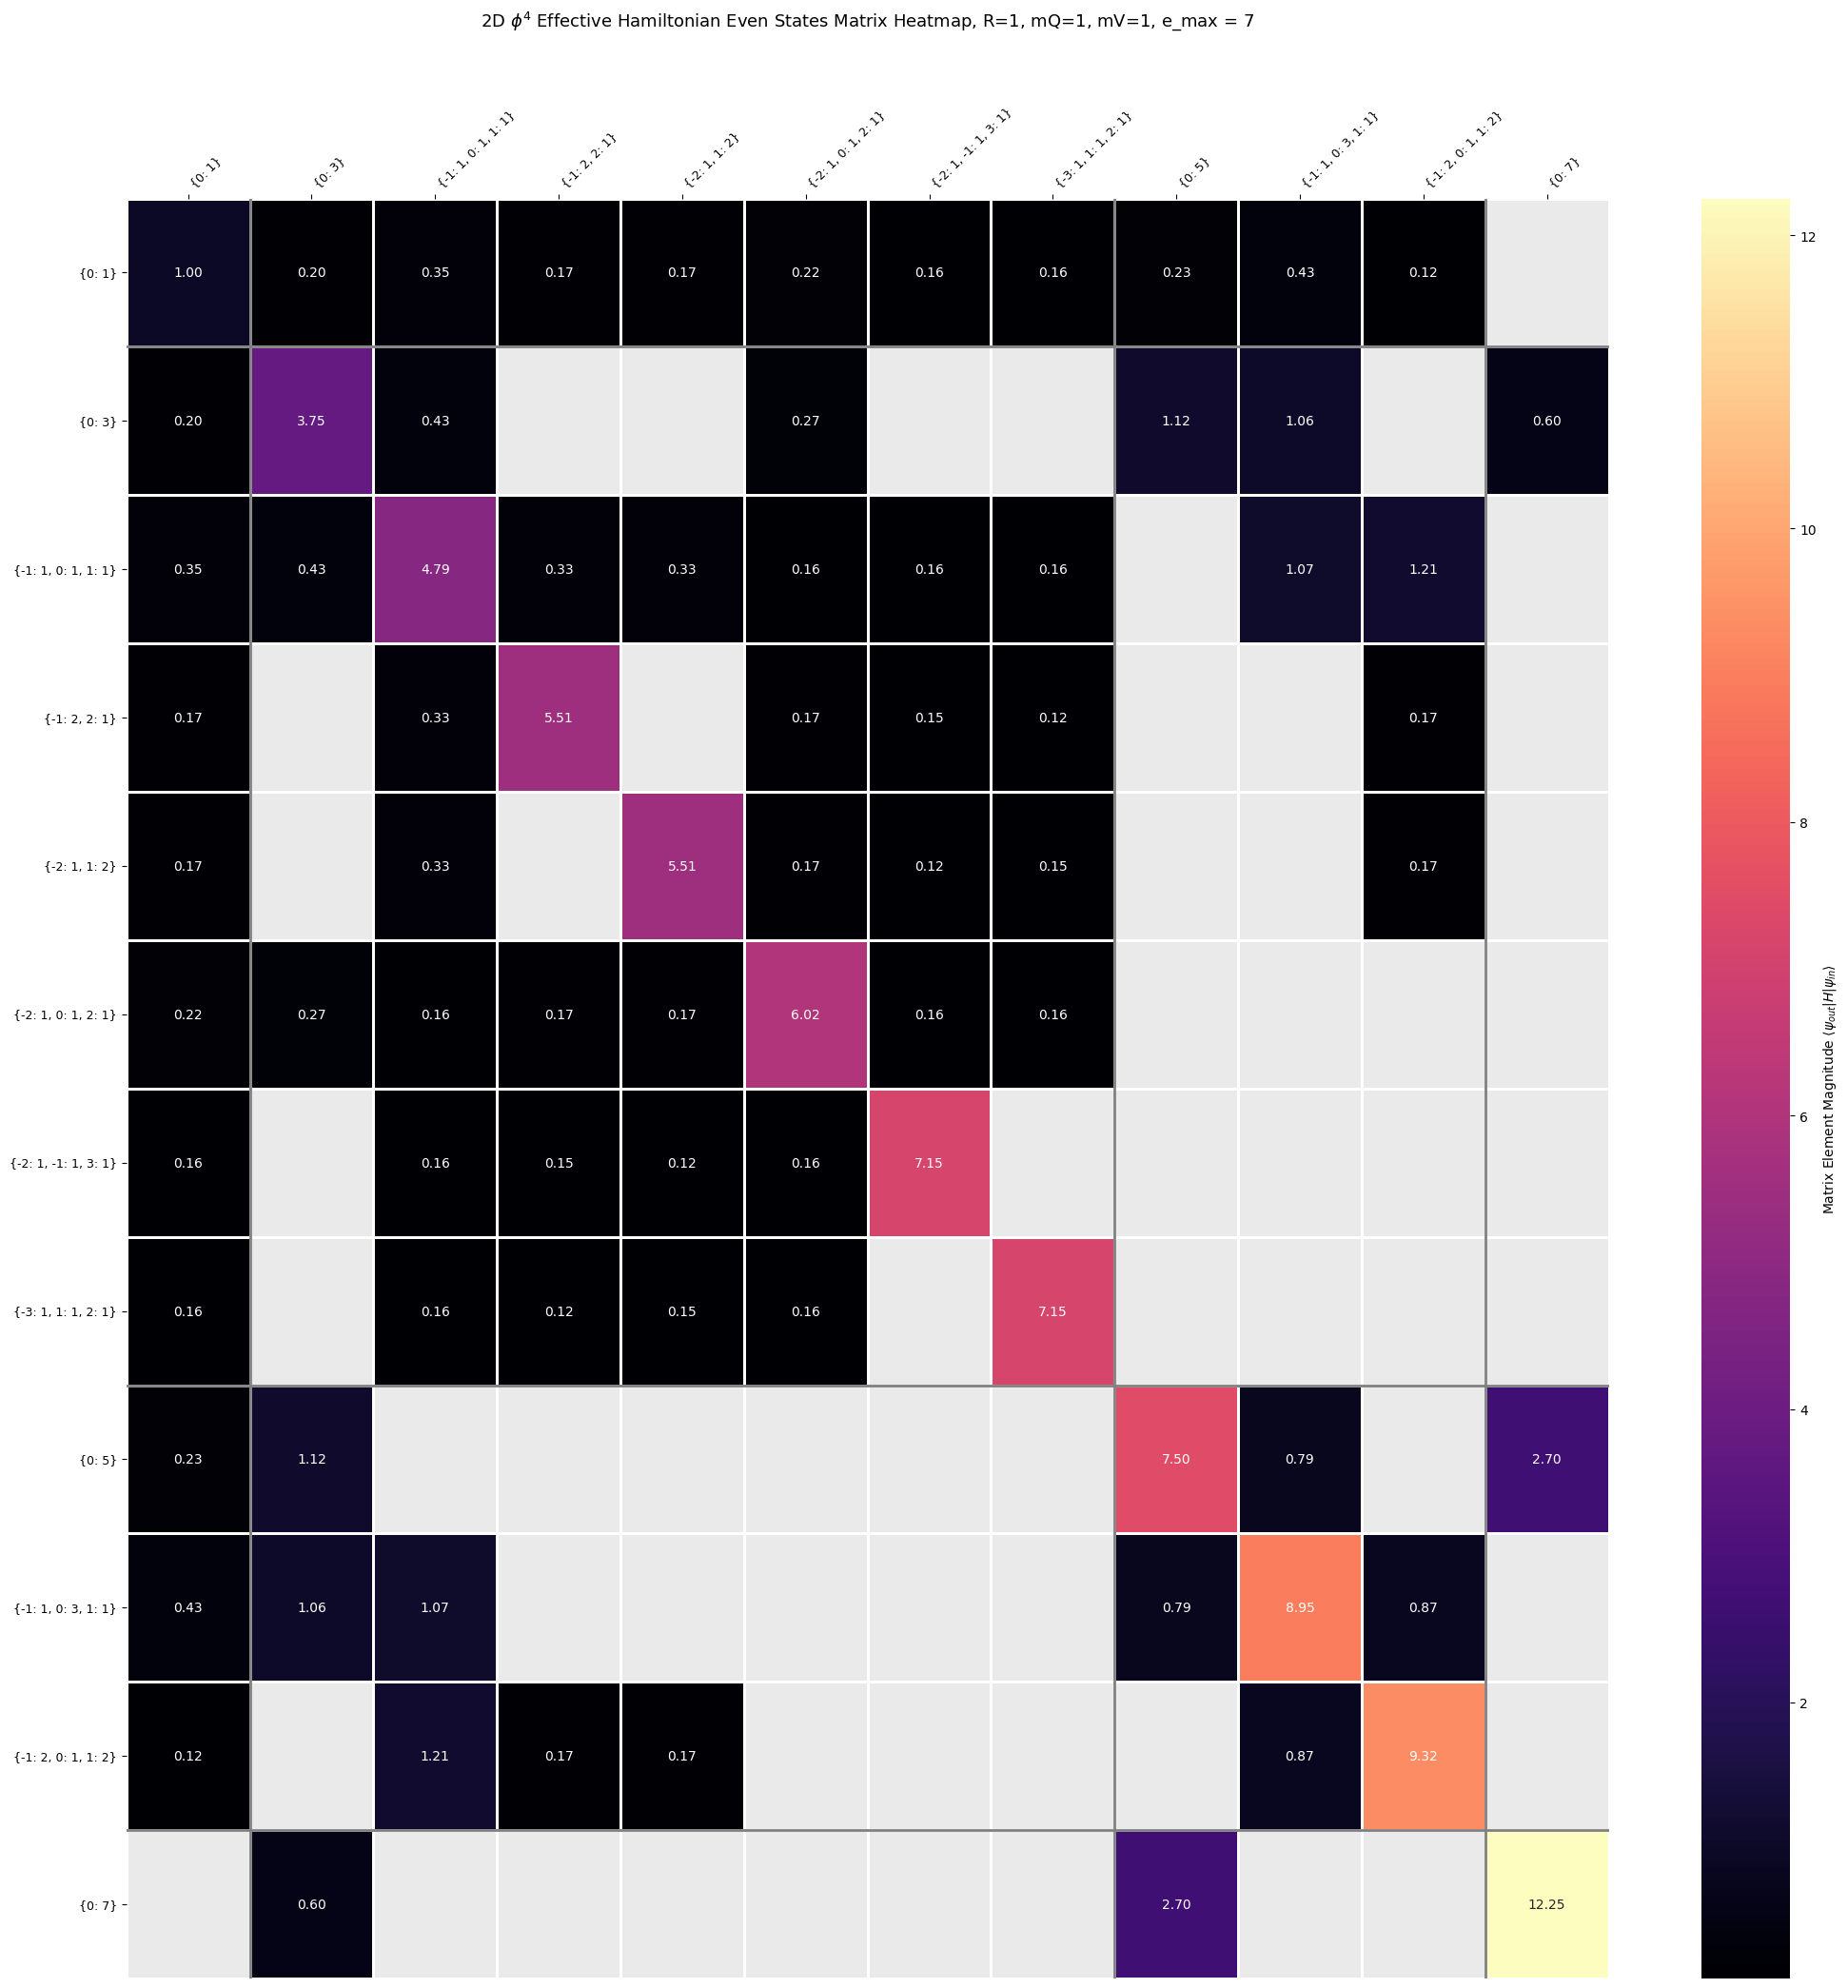

In [20]:
# --- Hamiltonian Parameters for Test ---
g = 4*np.pi; mV = 1; mQ=1; r = 1; e_max=7; lmaxeff = effective_lmax(e_max,e_max,mQ,r)

# --- Generate the Basis ---
reduced_basis, asymList, cD, hashable_basis = basis_odd(*gen_reduced_basis(lmaxeff,e_max,mQ,r)) #Select Even Basis States Only.

# Generate useful lists of energies.
gen_omega_list(lmaxeff, mQ, r)


# --- Run the transition matrix element calculation in phi^4 ---
H_eff_coo=transition_matrix_phi4(mQ, g, r, lmaxeff, reduced_basis, asymList, cD, hashable_basis)


# --- Prepare the Plot ---

# 1. Convert the reduced basis into the buffed version with both anti-symmetric pairs.
full_basis=convertBasis(reduced_basis, asymList)


# 2. Compute properties.
occupation_numbers = np.array([get_total_occupation_number(state) for state in full_basis]) # State Occupation Number for each in basis.
full_state_energies = np.array([get_state_energy(state, mQ, r) for state in full_basis]) ## State Energies for each in basis.


# 3. Sort the basis using lexsort, primarily by occupation number, secondly by energy.
double_sorted_indices = np.lexsort((full_state_energies, occupation_numbers)) 
sorted_full_basis = [full_basis[i] for i in double_sorted_indices]
H_sorted = H_eff_coo.toarray()[double_sorted_indices, :][:, double_sorted_indices]


# 4. Identify unique occupation values and their starting indices
# (Using the sorted array guarantees these indices mark the boundaries)
unique_occ, boundaries_vec = np.unique(occupation_numbers[double_sorted_indices], return_index=True)

# 5. Map the boundaries to a dictionary
boundaries = dict(zip(unique_occ, boundaries_vec))


# --- --- Plot --- ---

# --- State labels ---
verbose_labels = []
for state in sorted_full_basis:
    verbose_labels.append("{"+", ".join(f"{key}: {value}" for key, value in sorted(state.items()) if value !=0)+"}") # Such that they 'look' like a dictionary of states on the plot.

# --- Boundaries between occupation numbers for the plot ---
state_vecs = np.array([convert_state_to_list(state, lmaxeff) for state in sorted_full_basis])
boundaries = np.where(np.diff(np.sort(np.sum(state_vecs, axis=1))))[0] # List of places where state occupation number changes.
boundaries[0] = 0 # Fixing the zero entry.

# --- Plotting the Heatmap Matrix ---
plt.figure(figsize=(21, 21))

zero_mask = (H_sorted == 0.0) # So that we don't have an overcrowded plot.
ax = sns.heatmap(
    H_sorted, 
    annot=True, 
    fmt=".2f", 
    cmap="magma", 
    linewidths=0.8,
    xticklabels=verbose_labels, 
    yticklabels=verbose_labels,
    mask=zero_mask,
    cbar_kws={'label': 'Matrix Element Magnitude $\\langle \\psi_{out} | H | \\psi_{in} \\rangle$'}
)

# Drawing separation dividers between states of differing occupation number.
for b in boundaries:
    ax.axvline(x=b+1, linewidth=2, color="grey")
    ax.axhline(y=b+1, linewidth=2, color="grey")


ax.xaxis.tick_top() # Layout of x-axis.
ax.xaxis.set_label_position('top')
ax.set_facecolor('#eaeaea') # Soft gray for zero elements
plt.xticks(rotation=45, ha='left', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.title(rf"2D $\phi^4$ Effective Hamiltonian Even States Matrix Heatmap, R={r}, mQ={mQ}, mV={mV}, e_max = {e_max}", fontsize=13, pad=60)
plt.tight_layout()
plt.show()


## Timing Code to Compare with https://arxiv.org/abs/2110.08273

E_max: 7
 reduced basis length = 12 and number of asymmetric states = 1
 total basis length = 13
234 μs ± 3.21 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_max: 8
 reduced basis length = 17 and number of asymmetric states = 3
 total basis length = 20
451 μs ± 2.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_max: 9
 reduced basis length = 25 and number of asymmetric states = 5
 total basis length = 30
773 μs ± 4.69 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_max: 10
 reduced basis length = 35 and number of asymmetric states = 11
 total basis length = 46
1.43 ms ± 7.87 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_max: 11
 reduced basis length = 53 and number of asymmetric states = 20
 total basis length = 73
2.65 ms ± 80.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
E_max: 12
 reduced basis length = 73 and number of asymmetric states = 32
 total basis length = 105
4.35 ms ± 41 μs per loop (mean ± std. dev. of 7

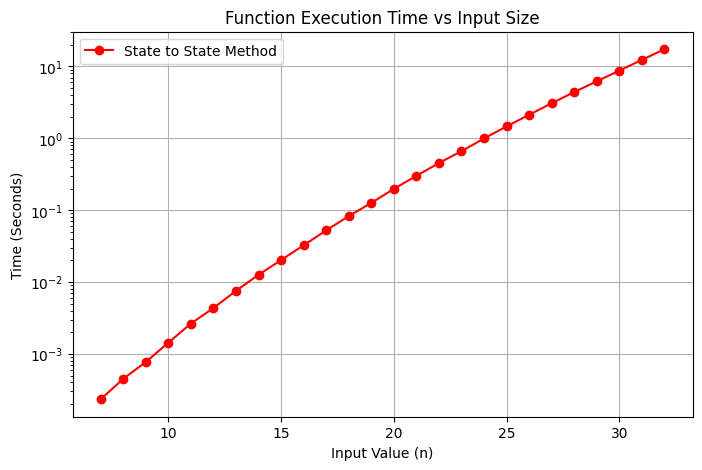

In [19]:
# 1. Preparing the parameters for the timing run, and lists for results.
mQ = 1; r = 1; g = 4*np.pi # Hamiltonian parameters.
execution_times = []; basis_lengths = []
emax_list = range(7,33) #EMax range.

# 2. Run through emax list and time creation.
for emax in emax_list:
    print(f"E_max: {emax}")

    # Timing the transition matrix creation.
    # Compute the effective lmax.
    lmaxeff = effective_lmax(emax,emax,mQ,r)
    # Generate the basis and energy list.
    basis, asymList, cD, hashable_basis = basis_even(*gen_reduced_basis(lmaxeff,emax,mQ,r))
    gen_omega_list(lmaxeff, mQ, r)

    # Just to keep track of the basis length and how much we've saved by only going through one set of an anti-symmetric pair.
    print(f' reduced basis length = {len(basis)} and number of asymmetric states = {len(asymList)}')
    print(f' total basis length = {len(basis)+len(asymList)}')

    # Timing: 
    duration = %timeit -o transition_matrix_phi4(mQ, g, r, lmaxeff, basis, asymList, cD, hashable_basis)
    # Add results to relevant lists.
    execution_times.append(duration.average)
    basis_lengths.append(len(basis))


# 3. Export results to a CSV file
csv_filename = "phi4_statetostate_results.csv"
with open(csv_filename, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(f"mQ = {mQ}, g = {g}, r = {r}") # To keep track of HT parameters.
    writer.writerow("EMax List")  # Writes emax list onto file header.
    writer.writerow(emax_list) # To keep track of the relevant emax's used.
    writer.writerow(["Input Value", "Execution Time (Seconds)"])  # Headers
    writer.writerows(zip(emax_list,execution_times))

# 4. Plot the results
plt.figure(figsize=(8, 5))
plt.yscale('log')
plt.plot(emax_list, execution_times, marker='o', linestyle='-', color='r', label="State to State Method")
plt.title('Function Execution Time vs Input Size')
plt.xlabel('Input Value (n)')
plt.ylabel('Time (Seconds)')
plt.legend()
plt.grid(True)
plt.show()